<a href="https://colab.research.google.com/github/decodewidwaiz/Ass_ignment-5/blob/main/gratebar_unet_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gratebar Defect Detection — U-Net Autoencoder (Good-Images-Only Training)

**Revised approach (per mentor guidance):** train only on good images. "Good" is
well-defined and learnable; "bad" is open-ended and shouldn't be modeled
directly.

**How this works:**
- U-Net is trained as a **denoising / inpainting autoencoder**: random patches
  of each good image are corrupted, and the network learns to reconstruct the
  original from context. (Plain autoencoder training would let the skip
  connections just copy pixels through and produce near-zero error everywhere,
  including on real defects -- the random corruption is what forces genuine
  learning of normal texture instead of that shortcut.)
- At inference: feed the network *any* image. It reconstructs faithfully where
  it has seen normal patterns before, and poorly where it hasn't (i.e. on a
  real defect). The reconstruction error map, thresholded, **is** the defect
  mask.
- **Bad images + their provided masks are never used for training** -- only to
  calibrate the error threshold and for final honest evaluation. No gradient
  from bad images ever touches the model, per the "train on good only" rule,
  while still using the labeled bad data you have for something useful.
- Output mask convention: **0 = no defect, 255 = defective pixel** (uint8), as
  specified.

Run cells top to bottom.

## 1. Setup

In [ ]:
!pip install -q albumentations==1.4.15


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 kB 13.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install --no-cache-dir --upgrade albumentations albucore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 62.6 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 1.4.15
    Uninstalling albumentations-1.4.15:
      Successfully uninstalled albumentations-1.4.15


In [ ]:
import os, glob, random, time, copy, re, csv
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print('Device:', device)


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.15). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.


Device: cuda


## 2. Config — EDIT THESE PATHS

- `GOOD_DIR` — folder with good images (used for training)
- `BAD_DIR` — folder with bad images (used ONLY for threshold calibration + final evaluation)
- `MASK_DIR` — folder with bad-image masks (filenames end with `_mask.jpeg`)

In [ ]:
GOOD_DIR = '/content/drive/MyDrive/P1_Dilated/Good'
BAD_DIR  = '/content/drive/MyDrive/P1_Dilated/Bad'
MASK_DIR = '/content/drive/MyDrive/P1_Dilated/Mask'

CHECKPOINT_DIR = '/content/drive/MyDrive/P1_Dilated/checkpoint'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LOG_CSV = os.path.join(CHECKPOINT_DIR, 'training_log.csv')

IMG_H, IMG_W   = 480, 768
BATCH_SIZE     = 12
NUM_WORKERS    = 0
EPOCHS         = 45
LR             = 1e-4
WEIGHT_DECAY   = 1e-4
WARMUP_EPOCHS  = 3
GRAD_CLIP_NORM = 1.0
EMA_DECAY      = 0.999
DROPOUT_P      = 0.2
MASK_THRESH    = 127          # binarization threshold for provided (jpeg-compressed) bad-image masks

# --- corruption (inpainting) settings, applied only to the AE input, never the target ---
NUM_PATCHES_RANGE  = (8, 16)  # how many random rectangles to corrupt per image
PATCH_SIZE_RANGE   = (15, 45) # patch side length in pixels, at 768x480 resolution

# --- splits ---
GOOD_TEST_FRAC  = 0.10
GOOD_VAL_FRAC_OF_REMAINDER = 0.15 / 0.90   # -> overall good: ~75% train / ~15% val / ~10% test
BAD_CALIB_FRAC  = 0.60        # fraction of bad images used to pick the error threshold
                               # remaining bad images are held out purely for final testing

BASE_CH   = 32
PATIENCE  = 12
RESUME    = True


## 2b. Stage dataset to local Colab disk (speed optimization)

Copies data to `/content/data` once per session so all reads happen locally
instead of over Drive's network I/O every epoch. Skips already-staged folders,
so it's cheap to re-run after a resume.

In [ ]:
import shutil

LOCAL_ROOT = '/content/data'
os.makedirs(LOCAL_ROOT, exist_ok=True)

def stage_local(src_dir, name):
    dst_dir = os.path.join(LOCAL_ROOT, name)
    if os.path.isdir(dst_dir) and len(os.listdir(dst_dir)) > 0:
        print(f'{name}: already staged ({len(os.listdir(dst_dir))} files)')
        return dst_dir
    print(f'Copying {name} -> {dst_dir} ...')
    shutil.copytree(src_dir, dst_dir)
    print(f'{name}: done ({len(os.listdir(dst_dir))} files)')
    return dst_dir

GOOD_DIR = stage_local(GOOD_DIR, 'good')
BAD_DIR  = stage_local(BAD_DIR, 'bad')
MASK_DIR = stage_local(MASK_DIR, 'bad_masks')


Copying good -> /content/data/good ...
good: done (3833 files)
Copying bad -> /content/data/bad ...
bad: done (1166 files)
Copying bad_masks -> /content/data/bad_masks ...
bad_masks: done (1166 files)


## 3. Build file list

In [ ]:
def list_images(d, exts=('.jpg', '.jpeg', '.png')):
    files = []
    for e in exts:
        files += glob.glob(os.path.join(d, f'*{e}'))
        files += glob.glob(os.path.join(d, f'*{e.upper()}'))
    return sorted(files)

good_images = list_images(GOOD_DIR)
bad_images  = list_images(BAD_DIR)

def find_mask_for(bad_path):
    stem = os.path.splitext(os.path.basename(bad_path))[0]
    candidate = os.path.join(MASK_DIR, f'{stem}_mask.jpeg')
    if os.path.exists(candidate):
        return candidate
    for e in ('.jpg', '.png', '.JPEG', '.JPG', '.PNG'):
        c = os.path.join(MASK_DIR, f'{stem}_mask{e}')
        if os.path.exists(c):
            return c
    return None

bad_pairs, missing = [], []
for bp in bad_images:
    mp = find_mask_for(bp)
    (missing if mp is None else bad_pairs).append(bp if mp is None else (bp, mp))

print(f'Good images: {len(good_images)}')
print(f'Bad images:  {len(bad_images)} | matched masks: {len(bad_pairs)} | missing masks: {len(missing)}')
if missing:
    print('First few missing:', missing[:5])


Good images: 3833
Bad images:  1166 | matched masks: 1166 | missing masks: 0


## 4. Group-aware splits (prevents near-duplicate frame leakage)

Frames are timestamped (`..._18-01-2025_00-01-47.jpeg`) from a fixed camera, so
frames close in time can look near-identical. Splits are grouped by date+hour so
no time-adjacent frames span across train/val/test.

In [ ]:
TIMESTAMP_RE = re.compile(r'(\d{2}-\d{2}-\d{4})_(\d{2})-(\d{2})-(\d{2})')

def get_group_key(path):
    fname = os.path.basename(path)
    m = TIMESTAMP_RE.search(fname)
    if m:
        date, hh, mm, ss = m.groups()
        return f'{date}_{hh}'
    return fname

def group_split_3way(samples, test_size, val_size_within_remainder, seed=SEED):
    if len(samples) < 6:
        return samples, [], []
    groups = [get_group_key(s if isinstance(s, str) else s[0]) for s in samples]
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(gss1.split(samples, groups=groups))
    trainval = [samples[i] for i in trainval_idx]
    test = [samples[i] for i in test_idx]
    groups_tv = [groups[i] for i in trainval_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size_within_remainder, random_state=seed)
    train_idx, val_idx = next(gss2.split(trainval, groups=groups_tv))
    train = [trainval[i] for i in train_idx]
    val = [trainval[i] for i in val_idx]
    return train, val, test

def group_split_2way(samples, split_frac, seed=SEED):
    """samples: list of (img_path, mask_path) tuples"""
    if len(samples) < 4:
        return samples, []
    groups = [get_group_key(s[0]) for s in samples]
    gss = GroupShuffleSplit(n_splits=1, test_size=(1 - split_frac), random_state=seed)
    a_idx, b_idx = next(gss.split(samples, groups=groups))
    return [samples[i] for i in a_idx], [samples[i] for i in b_idx]

# good images -> train / val / test (train for AE learning, val for early stopping +
# threshold noise-floor, test held out entirely until final evaluation)
good_train, good_val, good_test = group_split_3way(good_images, GOOD_TEST_FRAC, GOOD_VAL_FRAC_OF_REMAINDER)

# bad images -> calibration set (pick the error threshold) / test set (final honest check)
bad_calib, bad_test = group_split_2way(bad_pairs, BAD_CALIB_FRAC)

print(f'Good: train={len(good_train)}  val={len(good_val)}  test={len(good_test)}')
print(f'Bad:  calib={len(bad_calib)}  test={len(bad_test)}')
print('\nReminder: bad images are NEVER used for training, only for threshold calibration and the final test.')


Good: train=2789  val=643  test=401
Bad:  calib=704  test=462

Reminder: bad images are NEVER used for training, only for threshold calibration and the final test.


## 5. Datasets

Two dataset classes:
- `ReconstructionDataset` — good images only. Applies geometric/color
  augmentation, then randomly corrupts patches of the input (target stays
  clean). Used for training and val-loss tracking.
- `EvalDataset` — used for threshold calibration and final testing. No
  augmentation, no corruption. Returns the real ground-truth mask (zeros for
  good images, provided mask for bad images) purely for scoring.

In [ ]:
def random_cutout(img, num_patches_range, patch_size_range):
    """img: HxWx3 float32 in [0,1]. Returns a corrupted copy; img itself is untouched."""
    h, w = img.shape[:2]
    out = img.copy()
    n = random.randint(*num_patches_range)
    for _ in range(n):
        ph = random.randint(*patch_size_range)
        pw = random.randint(*patch_size_range)
        y = random.randint(0, max(0, h - ph))
        x = random.randint(0, max(0, w - pw))
        # fill with random noise (not a flat color) so the network can't shortcut
        # by learning "corrupted regions are always this exact value"
        out[y:y+ph, x:x+pw] = np.random.rand(ph, pw, 3).astype(np.float32)
    return out


geo_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.05, rotate_limit=5,
                        border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
])


class ReconstructionDataset(Dataset):
    def __init__(self, paths, augment_geo=True, apply_cutout=True):
        self.paths = paths
        self.augment_geo = augment_geo
        self.apply_cutout = apply_cutout

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0

        if self.augment_geo:
            img = geo_tf(image=img)['image']

        target = img.copy()
        corrupted = random_cutout(img, NUM_PATCHES_RANGE, PATCH_SIZE_RANGE) if self.apply_cutout else img.copy()

        input_t = torch.from_numpy(corrupted.transpose(2, 0, 1)).float()
        target_t = torch.from_numpy(target.transpose(2, 0, 1)).float()
        return input_t, target_t


class EvalDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        entry = self.samples[idx]

        # All entries are now expected to be 3-tuples (kind, img_path, mask_path)
        kind, img_path, mask_path = entry

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"CRITICAL ERROR: Failed to load image at: {img_path}. Original entry: {entry}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0

        if kind == 'good':
            mask = np.zeros((IMG_H, IMG_W), dtype=np.float32)
        else:
            if mask_path is None:
                raise ValueError(f"Mask path is None for a 'bad' sample at index {idx}: {entry}")
            m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if m is None:
                raise FileNotFoundError(f"CRITICAL ERROR: Failed to load mask at: {mask_path}. Original entry: {entry}")
            m = cv2.resize(m, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
            mask = (m > MASK_THRESH).astype(np.float32)

        img_t = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask_t = torch.from_numpy(mask).unsqueeze(0).float()
        kind_label = 1 if kind == 'bad' else 0
        return img_t, mask_t, kind_label

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 6. DataLoaders

In [ ]:
train_ds = ReconstructionDataset(good_train, augment_geo=True, apply_cutout=True)
val_recon_ds = ReconstructionDataset(good_val, augment_geo=False, apply_cutout=True)

# Modified: Ensure all eval samples have a consistent (kind, img_path, mask_path) structure
good_val_eval  = [('good', p, None) for p in good_val]
good_test_eval = [('good', p, None) for p in good_test]
bad_calib_eval = [('bad', p, m) for p, m in bad_calib]
bad_test_eval  = [('bad', p, m) for p, m in bad_test]

calib_ds = EvalDataset(good_val_eval + bad_calib_eval)
test_ds  = EvalDataset(good_test_eval + bad_test_eval)

# Keep training fast with workers
train_loader     = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                               persistent_workers=(NUM_WORKERS > 0))
val_recon_loader = DataLoader(val_recon_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True,
                               persistent_workers=(NUM_WORKERS > 0))

# --- FIX: Set num_workers=0 here to catch the path error instantly on the main thread ---
calib_loader     = DataLoader(calib_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader      = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train (AE): {len(train_ds)} | Val (AE loss): {len(val_recon_ds)}')
print(f'Calibration set: {len(calib_ds)} (good {len(good_val_eval)} / bad {len(bad_calib_eval)})')
print(f'Test set:        {len(test_ds)} (good {len(good_test_eval)} / bad {len(bad_test_eval)})')

Train (AE): 2789 | Val (AE loss): 643
Calibration set: 1347 (good 643 / bad 704)
Test set:        863 (good 401 / bad 462)


## 7. U-Net Autoencoder

Same U-Net shape as a segmentation model, but now outputs a **3-channel
reconstructed image** (sigmoid-bounded to [0,1]) instead of a 1-channel defect
logit. Dropout at the bottleneck adds regularization on top of the corruption
scheme.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch, dropout=dropout))
    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        diffY = skip.size(2) - x.size(2)
        diffX = skip.size(3) - x.size(3)
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNetAutoencoder(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=32, dropout=0.0):
        super().__init__()
        self.inc   = DoubleConv(in_ch, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.down4 = Down(base * 8, base * 16, dropout=dropout)

        self.up1 = Up(base * 16, base * 8, base * 8)
        self.up2 = Up(base * 8, base * 4, base * 4)
        self.up3 = Up(base * 4, base * 2, base * 2)
        self.up4 = Up(base * 2, base, base)

        self.outc = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return torch.sigmoid(self.outc(x))   # bounded [0,1] to match normalized pixel range


model = UNetAutoencoder(in_ch=3, out_ch=3, base=BASE_CH, dropout=DROPOUT_P).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'U-Net Autoencoder parameters: {n_params:,}')


U-Net Autoencoder parameters: 7,763,107


## 8. EMA (Exponential Moving Average) of weights

In [ ]:
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        ema_params = dict(self.ema.named_parameters())
        model_params = dict(model.named_parameters())
        for name, p in model_params.items():
            ema_params[name].mul_(self.decay).add_(p.detach(), alpha=1 - self.decay)
        ema_buffers = dict(self.ema.named_buffers())
        model_buffers = dict(model.named_buffers())
        for name, b in model_buffers.items():
            ema_buffers[name].copy_(b)

ema = ModelEMA(model, decay=EMA_DECAY)


## 9. Reconstruction loss

In [ ]:
class ReconLoss(nn.Module):
    """L1 (robust to outliers, sharper edges) + a small MSE term (penalizes large errors more)."""
    def __init__(self, l1_weight=0.8):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.mse = nn.MSELoss()
        self.l1_weight = l1_weight
    def forward(self, recon, target):
        return self.l1_weight * self.l1(recon, target) + (1 - self.l1_weight) * self.mse(recon, target)

criterion = ReconLoss(l1_weight=0.8)


In [ ]:
# The following `__getitem__` function was incorrectly defined as a standalone function
# and is likely causing issues. The correct `__getitem__` method is part of the `EvalDataset` class.
# Original incorrect code:
# def __getitem__(self, idx):
#         entry = self.samples[idx]
#         if len(entry) == 2:
#             kind, img_path = 'good', entry[0]
#             mask_path = None
#         else:
#             kind, img_path, mask_path = 'bad', entry[0], entry[1]

#         img = cv2.imread(img_path, cv2.IMREAD_COLOR)

#         # --- FIX: Track missing image paths ---
#         if img is None:
#             raise FileNotFoundError(f"Missing or corrupted image file: {img_path}")

#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0

#         if kind == 'good':
#             mask = np.zeros((IMG_H, IMG_W), dtype=np.float32)
#         else:
#             m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

#             # --- FIX: Track missing mask paths ---
#             if m is None:
#                 raise FileNotFoundError(f"Missing or corrupted mask file: {mask_path}")

#             m = cv2.resize(m, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
#             mask = (m > MASK_THRESH).astype(np.float32)

#         img_t = torch.from_numpy(img.transpose(2, 0, 1)).float()
#         mask_t = torch.from_numpy(mask).unsqueeze(0).float()
#         kind_label = 1 if kind == 'bad' else 0
#         return img_t, mask_t, kind_label


## 10. Training loop

Trains the autoencoder on good images only. Validation loss (Section 6's
`val_recon_loader`) drives early stopping and best-checkpoint selection --
still using only good data, never bad. AdamW + weight decay, warmup + plateau
scheduling, gradient clipping, EMA, resume-from-checkpoint, and CSV logging are
all carried over from the earlier pipeline.

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
scaler = torch.cuda.amp.GradScaler()

latest_path = os.path.join(CHECKPOINT_DIR, 'ae_latest.pth')
best_path   = os.path.join(CHECKPOINT_DIR, 'ae_best.pth')

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
start_epoch = 1
patience_ctr = 0

if RESUME and os.path.exists(latest_path):
    ckpt = torch.load(latest_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    ema.ema.load_state_dict(ckpt['ema_state_dict'])
    history = ckpt['history']
    best_val_loss = ckpt['best_val_loss']
    patience_ctr = ckpt['patience_ctr']
    start_epoch = ckpt['epoch'] + 1
    print(f'Resumed from epoch {ckpt["epoch"]}, continuing at epoch {start_epoch}.')
else:
    print('Starting fresh training run.')
    if not os.path.exists(LOG_CSV):
        with open(LOG_CSV, 'w', newline='') as f:
            csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'lr'])

for epoch in range(start_epoch, EPOCHS + 1):
    if epoch <= WARMUP_EPOCHS:
        warmup_lr = LR * epoch / WARMUP_EPOCHS
        for g in optimizer.param_groups:
            g['lr'] = warmup_lr

    model.train()
    running_loss = 0.0
    t0 = time.time()
    for corrupted, target in train_loader:
        corrupted, target = corrupted.to(device, non_blocking=True), target.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            recon = model(corrupted)
            loss = criterion(recon, target)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        running_loss += loss.item() * corrupted.size(0)
    train_loss = running_loss / len(train_ds)

    model.eval()
    val_loss, n = 0.0, 0
    with torch.no_grad():
        for corrupted, target in val_recon_loader:
            corrupted, target = corrupted.to(device), target.to(device)
            with torch.cuda.amp.autocast():
                recon = model(corrupted)
                loss = criterion(recon, target)
            val_loss += loss.item() * corrupted.size(0)
            n += corrupted.size(0)
    val_loss /= n

    if epoch > WARMUP_EPOCHS:
        scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    dt = time.time() - t0
    print(f'Epoch {epoch:03d}/{EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | '
          f'lr {current_lr:.2e} | {dt:.1f}s')

    with open(LOG_CSV, 'a', newline='') as f:
        csv.writer(f).writerow([epoch, train_loss, val_loss, current_lr])

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'ema_state_dict': ema.ema.state_dict(),
        'history': history,
        'best_val_loss': best_val_loss,
        'patience_ctr': patience_ctr,
        'img_h': IMG_H, 'img_w': IMG_W, 'base_ch': BASE_CH,
    }, latest_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.ema.state_dict(),
            'val_loss': val_loss,
            'img_h': IMG_H, 'img_w': IMG_W, 'base_ch': BASE_CH,
        }, best_path)
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch} (no val_loss improvement for {PATIENCE} epochs).')
            break

print(f'Best val loss: {best_val_loss:.4f}')
best_ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
ema.ema.load_state_dict(best_ckpt['ema_state_dict'])


Starting fresh training run.


/tmp/ipykernel_1355/200199693.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1355/200199693.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1355/200199693.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/45 | train_loss 0.0506 | val_loss 0.0196 | lr 3.33e-05 | 243.4s
Epoch 002/45 | train_loss 0.0221 | val_loss 0.0127 | lr 6.67e-05 | 205.3s
Epoch 003/45 | train_loss 0.0181 | val_loss 0.0108 | lr 1.00e-04 | 203.8s
Epoch 004/45 | train_loss 0.0182 | val_loss 0.0126 | lr 1.00e-04 | 203.5s
Epoch 005/45 | train_loss 0.0170 | val_loss 0.0083 | lr 1.00e-04 | 204.9s
Epoch 006/45 | train_loss 0.0175 | val_loss 0.0089 | lr 1.00e-04 | 204.4s
Epoch 007/45 | train_loss 0.0172 | val_loss 0.0074 | lr 1.00e-04 | 202.4s
Epoch 008/45 | train_loss 0.0175 | val_loss 0.0088 | lr 1.00e-04 | 205.7s
Epoch 009/45 | train_loss 0.0183 | val_loss 0.0095 | lr 1.00e-04 | 205.7s
Epoch 010/45 | train_loss 0.0153 | val_loss 0.0075 | lr 1.00e-04 | 203.6s
Epoch 011/45 | train_loss 0.0161 | val_loss 0.0067 | lr 1.00e-04 | 206.7s
Epoch 012/45 | train_loss 0.0150 | val_loss 0.0058 | lr 1.00e-04 | 206.5s
Epoch 013/45 | train_loss 0.0169 | val_loss 0.0089 | lr 1.00e-04 | 203.0s
Epoch 014/45 | train_loss 0.0149 | val

<All keys matched successfully>

## 11. Training curves

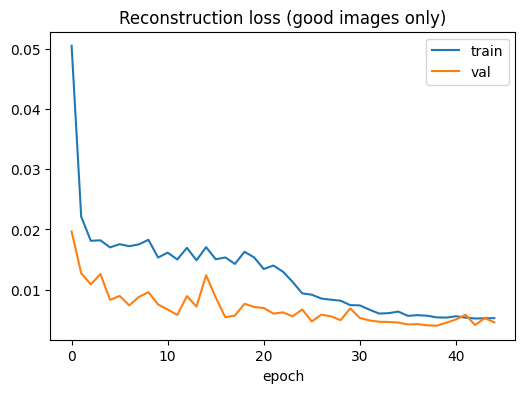

Both curves should fall together and roughly track each other.
train falling while val stalls/rises -> overfitting to the corruption pattern (raise DROPOUT_P, more augmentation, or fewer epochs).
Both flat/high -> underfitting (increase BASE_CH, train longer, or check LR).


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Reconstruction loss (good images only)'); plt.xlabel('epoch'); plt.legend()
plt.show()

print('Both curves should fall together and roughly track each other.')
print('train falling while val stalls/rises -> overfitting to the corruption pattern (raise DROPOUT_P, '
      'more augmentation, or fewer epochs).')
print('Both flat/high -> underfitting (increase BASE_CH, train longer, or check LR).')


## 12. Reconstruction error map + threshold calibration

Error map = mean absolute difference between input and reconstruction, per
pixel. Threshold is swept on the **calibration set** (good_val + bad_calib) --
never on the final test set -- and the value maximizing mean Dice is kept.
Post-processing (small morphological opening) removes speckle noise from the
raw error map before scoring.

In [ ]:
def clean_mask(mask_uint8, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    return cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel)

@torch.no_grad()
def error_map(net, img_tensor):
    with torch.amp.autocast('cuda'):
        recon = net(img_tensor)
    err = (img_tensor - recon).abs().mean(dim=1, keepdim=True)
    return err, recon

@torch.no_grad()
def sweep_threshold(net, loader, thresholds=np.arange(0.03, 0.31, 0.02)):
    net.eval()
    all_err, all_targets = [], []

    for imgs, masks, _ in loader:
        imgs = imgs.to(device)
        err, _ = error_map(net, imgs)
        all_err.append(err.cpu())
        all_targets.append(masks)

    all_err = torch.cat(all_err)
    all_targets = torch.cat(all_targets)

    best_t, best_dice = thresholds[0], -1
    results = []
    for t in thresholds:
        preds = (all_err > t).float()
        p = preds.view(preds.size(0), -1)
        y = all_targets.view(all_targets.size(0), -1)
        inter = (p * y).sum(dim=1)
        dice = ((2 * inter + 1e-7) / (p.sum(dim=1) + y.sum(dim=1) + 1e-7)).mean().item()
        results.append((round(float(t), 3), dice))
        if dice > best_dice:
            best_dice, best_t = dice, float(t)
    return best_t, best_dice, results

# --- Execute with explicit try-catch log mapping ---
BEST_THRESH, best_calib_dice, sweep_results = sweep_threshold(ema.ema, calib_loader)
print('Threshold sweep (error threshold, calibration Dice):')
for t, d in sweep_results:
    marker = '  <-- best' if abs(t - BEST_THRESH) < 1e-6 else ''
    print(f'  {t:.3f}: {d:.4f}{marker}')
print(f'\nUsing BEST_THRESH = {BEST_THRESH:.3f}')

Threshold sweep (error threshold, calibration Dice):
  0.030: 0.0006
  0.050: 0.0002
  0.070: 0.0060
  0.090: 0.0846
  0.110: 0.2413
  0.130: 0.3370
  0.150: 0.4039
  0.170: 0.4410
  0.190: 0.4588
  0.210: 0.4677
  0.230: 0.4736
  0.250: 0.4759
  0.270: 0.4766
  0.290: 0.4766
  0.310: 0.4774  <-- best

Using BEST_THRESH = 0.310


## 13. Held-out test set evaluation

`good_test` + `bad_test` — neither used for training nor threshold selection.
This is the honest, final number.

In [ ]:
@torch.no_grad()
def evaluate_test(net, loader, thresh, use_cleanup=True):
    net.eval()
    dices, ious = [], []
    y_true, y_pred = [], []
    for imgs, masks, kinds in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        err, _ = error_map(net, imgs)
        preds = (err > thresh).float().cpu().numpy()

        if use_cleanup:
            cleaned = np.stack([clean_mask((preds[i, 0] * 255).astype(np.uint8)) > 0 for i in range(preds.shape[0])])
            preds = cleaned.astype(np.float32)[:, None, :, :]

        preds_t = torch.from_numpy(preds)
        p = preds_t.view(preds_t.size(0), -1)
        y = masks.cpu().view(masks.size(0), -1)
        inter = (p * y).sum(dim=1)
        dice = (2 * inter + 1e-7) / (p.sum(dim=1) + y.sum(dim=1) + 1e-7)
        union = p.sum(dim=1) + y.sum(dim=1) - inter
        iou = (inter + 1e-7) / (union + 1e-7)
        dices.extend(dice.tolist())
        ious.extend(iou.tolist())

        pred_positive = (p.sum(dim=1) > 0).long().tolist()
        y_pred.extend(pred_positive)
        y_true.extend([int(k) for k in kinds])

    print(f'Test Dice (mean, good+bad): {np.mean(dices):.4f}')
    print(f'Test IoU  (mean, good+bad): {np.mean(ious):.4f}')

    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    print(f'\nImage-level (good=0 / bad=1) -- Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}')
    cm = confusion_matrix(y_true, y_pred)
    print('Confusion matrix [rows=true, cols=pred] (order: good, bad):')
    print(cm)
    return dices, ious, y_true, y_pred

test_dices, test_ious, y_true, y_pred = evaluate_test(ema.ema, test_loader, BEST_THRESH)


Test Dice (mean, good+bad): 0.4658
Test IoU  (mean, good+bad): 0.4658

Image-level (good=0 / bad=1) -- Precision: 0.0000  Recall: 0.0000  F1: 0.0000
Confusion matrix [rows=true, cols=pred] (order: good, bad):
[[401   0]
 [462   0]]


## 14. Qualitative check: input / reconstruction / error map / predicted mask / ground truth

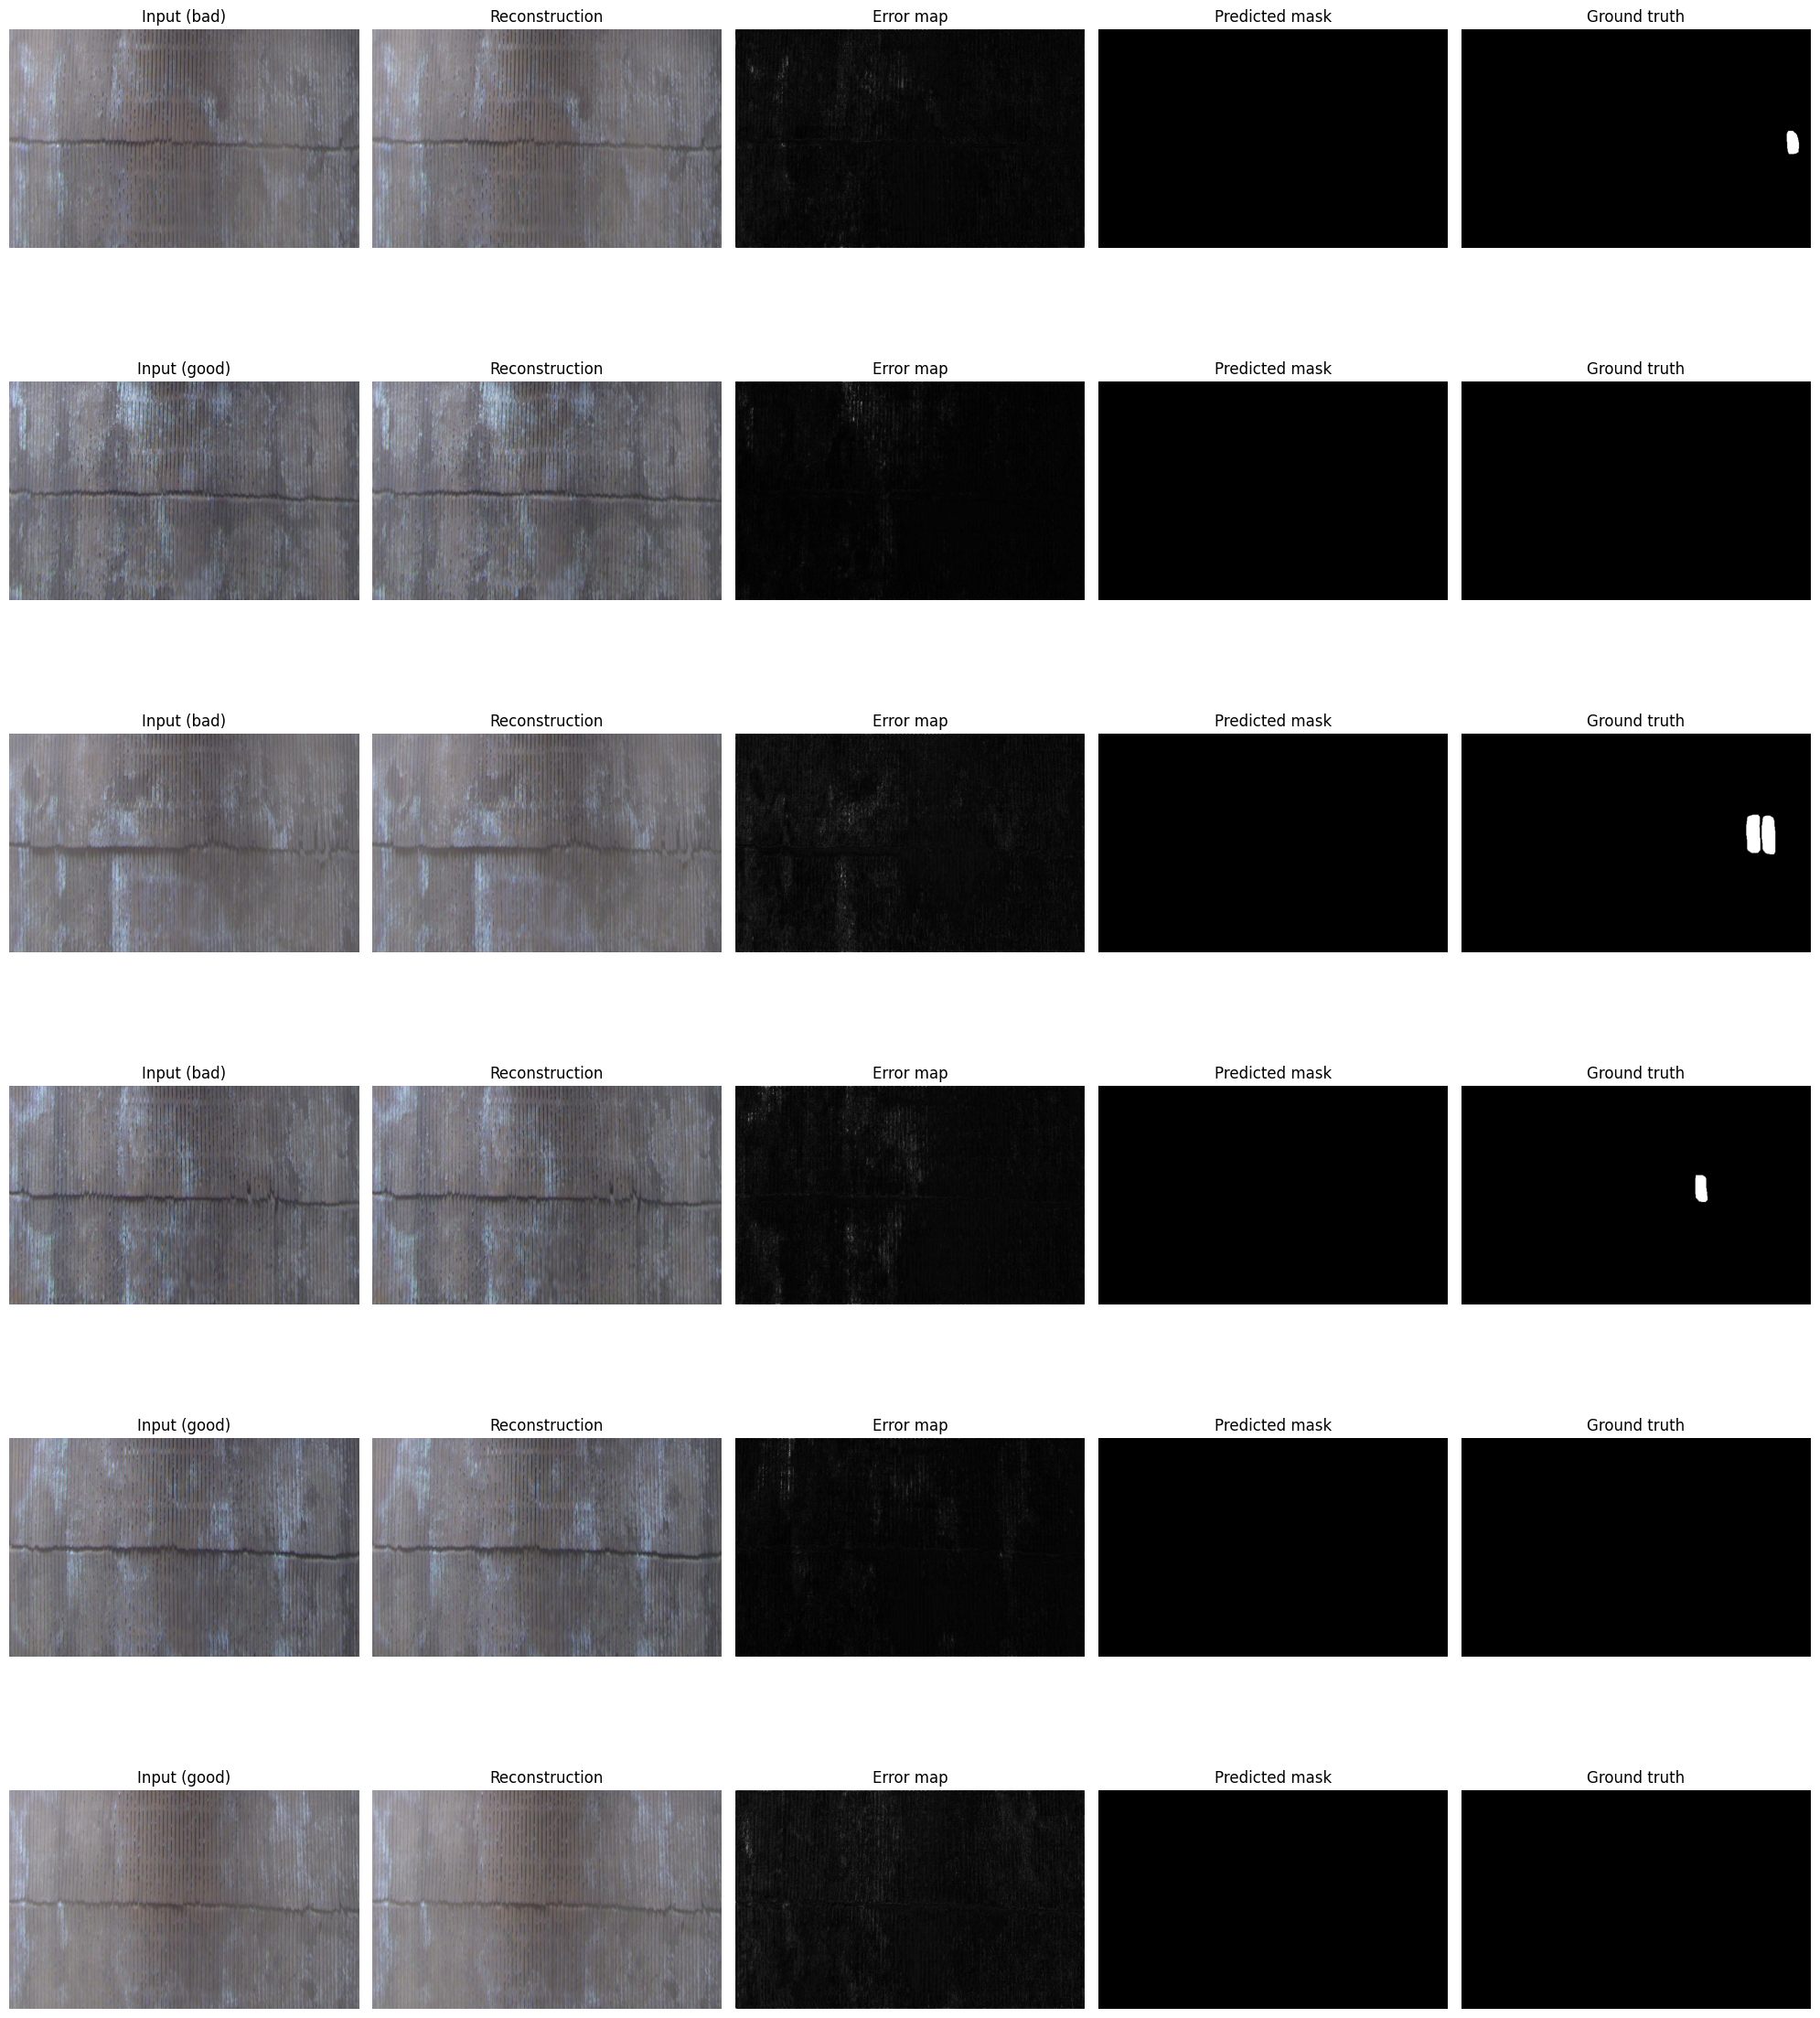

In [59]:
@torch.no_grad()
def show_test_samples(net, dataset, n=6, thresh=BEST_THRESH):
    net.eval()
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(len(idxs), 5, figsize=(20, 4 * len(idxs)))
    if len(idxs) == 1:
        axes = axes[None, :]
    titles = ['Input', 'Reconstruction', 'Error map', 'Predicted mask', 'Ground truth']
    for row, idx in enumerate(idxs):
        img_t, mask_t, kind = dataset[idx]
        img_b = img_t.unsqueeze(0).to(device)
        err, recon = error_map(net, img_b)

        pred = (err[0, 0].cpu().numpy() > thresh).astype(np.uint8)
        pred = (clean_mask(pred * 255) > 0).astype(np.float32)

        # --- FIX: Force all arrays to explicit, contiguous float32 types ---
        imgs_to_show = [
            img_t.permute(1, 2, 0).numpy().astype(np.float32),
            recon[0].permute(1, 2, 0).cpu().numpy().astype(np.float32),
            err[0, 0].cpu().numpy().astype(np.float32),
            pred.astype(np.float32),
            mask_t[0].numpy().astype(np.float32),
        ]

        for col, (im, title) in enumerate(zip(imgs_to_show, titles)):
            cmap = 'gray' if col >= 2 else None
            # Clip safely and render the normalized standard array
            axes[row, col].imshow(np.clip(im, 0.0, 1.0), cmap=cmap)
            axes[row, col].set_title(f"{title}" + (f" ({'bad' if kind else 'good'})" if col == 0 else ''))
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_test_samples(ema.ema, test_ds, n=6)

## 15. Inference on an arbitrary image

Returns a mask with **0 = no defect, 255 = defective pixel** (uint8), matching
the required output convention.

In [63]:
def predict_mask(image_path, thresh=None, use_ema=True, use_cleanup=True):
    thresh = BEST_THRESH if thresh is None else thresh
    net = ema.ema if use_ema else model
    net.eval()

    orig = cv2.imread(image_path, cv2.IMREAD_COLOR)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = orig.shape[:2]

    img = cv2.resize(orig, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    img_t = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

    with torch.no_grad():
        err, recon = error_map(net, img_t)
    err_np = err[0, 0].cpu().numpy()

    pred_mask = (err_np > thresh).astype(np.uint8) * 255
    if use_cleanup:
        pred_mask = clean_mask(pred_mask)

    pred_mask_full = cv2.resize(pred_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    pred_mask_full = (pred_mask_full > 127).astype(np.uint8) * 255   # re-binarize to clean 0/255 after resize

    defect_pixels = int((pred_mask_full > 0).sum())
    verdict = 'BAD (defect detected)' if defect_pixels > 0 else 'GOOD (no defect)'

    overlay = orig.copy()
    overlay[pred_mask_full > 0] = [255, 0, 0]
    blended = cv2.addWeighted(orig, 0.7, overlay, 0.3, 0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(orig); axes[0].set_title('Input'); axes[0].axis('off')
    axes[1].imshow(pred_mask_full, cmap='gray'); axes[1].set_title(f'Mask (0/255) -- {defect_pixels} px'); axes[1].axis('off')
    axes[2].imshow(blended); axes[2].set_title(verdict); axes[2].axis('off')
    plt.tight_layout(); plt.show()

    return pred_mask_full, verdict   # pred_mask_full: uint8 array, values in {0, 255}

# Example usage:
# mask, verdict = predict_mask('/content/drive/MyDrive/gratebar_dataset/some_test_image.jpeg')


## 16. Batch inference: save mask images for a whole folder

Runs inference on every image in a folder and writes each mask as a PNG (0/255
pixel values) to an output folder -- useful for processing a full inspection
run at once.

In [57]:
def batch_predict_and_save(input_dir, output_dir, thresh=None):
    os.makedirs(output_dir, exist_ok=True)
    paths = list_images(input_dir)
    for p in paths:
        mask, verdict = predict_mask(p, thresh=thresh)
        plt.close('all')  # avoid accumulating figures in a long batch run
        stem = os.path.splitext(os.path.basename(p))[0]
        out_path = os.path.join(output_dir, f'{stem}_mask.png')
        cv2.imwrite(out_path, mask)
    print(f'Saved {len(paths)} masks to {output_dir}')

# Example usage:
# batch_predict_and_save('/content/drive/MyDrive/gratebar_dataset/new_images',
#                         '/content/drive/MyDrive/gratebar_dataset/predicted_masks')


## 17. Save final model (raw + EMA weights, tuned threshold, config)

In [58]:
final_path = os.path.join(CHECKPOINT_DIR, 'ae_final.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'ema_state_dict': ema.ema.state_dict(),
    'best_thresh': BEST_THRESH,
    'img_h': IMG_H, 'img_w': IMG_W, 'base_ch': BASE_CH, 'dropout': DROPOUT_P,
}, final_path)
print('Saved to', final_path)

# To reload later in a fresh session:
# ckpt = torch.load(final_path, map_location=device)
# model = UNetAutoencoder(in_ch=3, out_ch=3, base=ckpt['base_ch'], dropout=ckpt.get('dropout', 0.0)).to(device)
# model.load_state_dict(ckpt['ema_state_dict'])   # EMA weights recommended
# BEST_THRESH = ckpt['best_thresh']


Saved to /content/drive/MyDrive/P1_Dilated/checkpoint/ae_final.pth


## Notes

- **Training never sees bad images or their masks.** Bad data is used only in
  Sections 12 (threshold calibration) and 13 (final test) -- no gradient from
  it ever touches the model, per the "train on good only" requirement.
- **If a session disconnects:** re-run from the top. Section 2b re-stages data,
  Section 10 auto-resumes from `ae_latest.pth`.
- **Reading results:** Section 11's curves show training health; Section 13's
  test Dice/IoU + confusion matrix is the honest final number; Section 14 lets
  you eyeball specific failures the metrics might hide.
- If test Dice comes back low, the most common fixes for this style of model
  are: increasing `NUM_PATCHES_RANGE`/corruption strength (forces the network
  to rely on the bottleneck more, less on skip-connection shortcuts), or
  lowering `BASE_CH` (less capacity to memorize a shortcut).

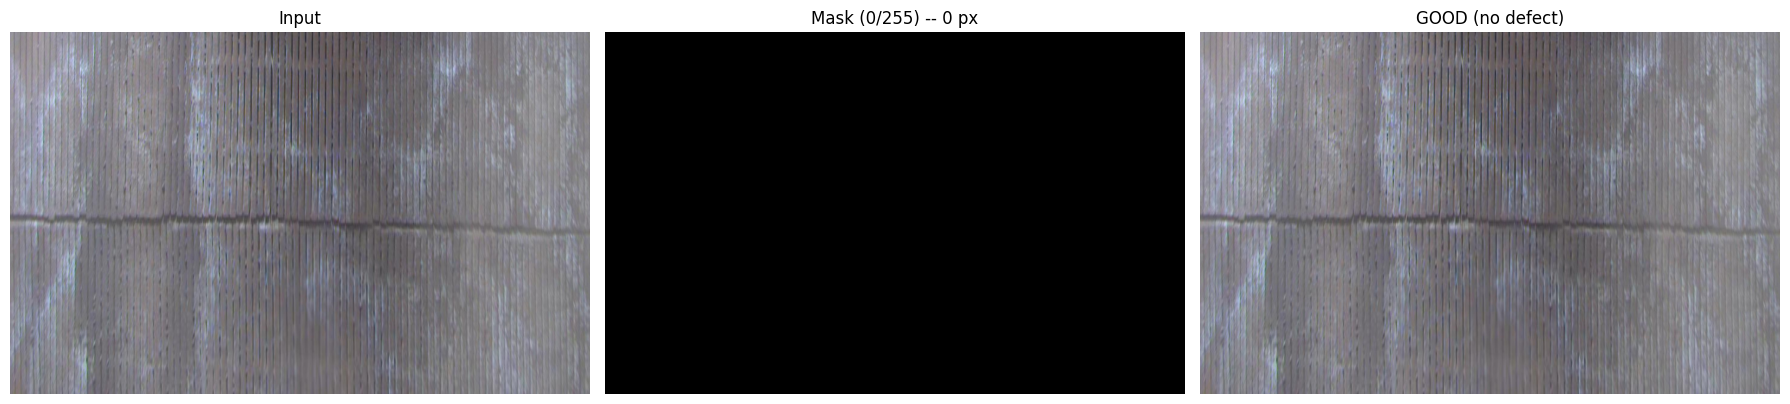

Prediction complete! Model verdict: GOOD (no defect)
Output mask unique values: [0]


In [60]:
# --- RUN ARBITRARY INFERENCE TO TEST THE MODEL ---

# 1. Update this path to any image inside your /content/data/ directory
TEST_IMAGE_PATH = '/content/data/good/SP2_M1_C2_F2_18-01-2025_00-30-51.jpeg'  # Replace with your actual file name

# 2. Run the prediction function
try:
    if not os.path.exists(TEST_IMAGE_PATH):
        raise FileNotFoundError(f"Could not find file at: {TEST_IMAGE_PATH}. Check your path syntax.")

    mask, verdict = predict_mask(TEST_IMAGE_PATH, thresh=BEST_THRESH)
    print(f"Prediction complete! Model verdict: {verdict}")
    print(f"Output mask unique values: {np.unique(mask)}") # Should show [0] or [0, 255]

except NameError:
    print("Error: Ensure you have executed the cell defining 'predict_mask' and 'BEST_THRESH' first.")
except Exception as e:
    print(f"An error occurred: {e}")